# Bike Availability Modeling
本 notebook 将流程拆成两部分：
1. 数据清洗（Data Cleaning）
2. 模型训练（Model Training）


## Part A: 数据清洗（Data Cleaning）
读取原始数据，完成时间/天气特征和 lag 特征构造，产出 `df_clean`。


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

INTERVALS_PER_DAY = 144
INTERVALS_PER_WEEK = 1008

# --- 路径定位（支持在项目根目录或 machine_learning 目录运行）---
cwd = Path.cwd()
if (cwd / "final_merged_data.csv.gz").exists():
    base_dir = cwd
elif (cwd / "machine_learning" / "final_merged_data.csv.gz").exists():
    base_dir = cwd / "machine_learning"
else:
    raise FileNotFoundError("Cannot find final_merged_data.csv.gz in current folder or ./machine_learning")

raw_path = base_dir / "final_merged_data.csv.gz"
print(f"Loading raw data from: {raw_path}")

# --- 读取原始数据 ---
df = pd.read_csv(raw_path)


# --- 时间字段清洗 ---
df['last_reported'] = pd.to_datetime(df['last_reported'], errors='coerce')
df = df.dropna(subset=['last_reported', 'station_id', 'num_bikes_available']).copy()

# --- 时间特征（直接使用原始 day/hour/minute 列）---
for c in ['day', 'hour', 'minute']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.dropna(subset=['day', 'hour', 'minute']).copy()
df['day'] = df['day'].astype(int)
df['hour'] = df['hour'].astype(int)
df['minute'] = df['minute'].astype(int)
# df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
# df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
# df['day_sin'] = np.sin(2 * np.pi * (df['day'] - 1) / 31)
# df['day_cos'] = np.cos(2 * np.pi * (df['day'] - 1) / 31)



# --- 温度均值 ---
if 'max_air_temperature_celsius' not in df.columns or 'min_air_temperature_celsius' not in df.columns:
    raise KeyError("Missing required temperature columns: max_air_temperature_celsius, min_air_temperature_celsius")
df['average_temperature_celsius'] = (
    df['max_air_temperature_celsius'] + df['min_air_temperature_celsius']
) / 2.0

# --- 气压均值 ---
if 'max_barometric_pressure_hpa' not in df.columns or 'min_barometric_pressure_hpa' not in df.columns:
    raise KeyError("Missing required pressure columns: max_barometric_pressure_hpa, min_barometric_pressure_hpa")
df['average_pressure_hpa'] = (
    df['max_barometric_pressure_hpa'] + df['min_barometric_pressure_hpa']
) / 2.0

# --- 湿度类别 ---
if 'max_relative_humidity_percent' not in df.columns or 'min_relative_humidity_percent' not in df.columns:
    raise KeyError("Missing required humidity columns: max_relative_humidity_percent, min_relative_humidity_percent")
df['average_humidity_percent'] = (
    df['max_relative_humidity_percent'] + df['min_relative_humidity_percent']
) / 2.0

df['very_humid'] = (df['average_humidity_percent'] >= 90).astype(int)

# --- lag 特征（按站点，shift(1) 防泄漏）---
df = df.sort_values(['station_id', 'last_reported']).reset_index(drop=True)
by_station = df.groupby('station_id')['num_bikes_available']

df['bikes_1d_mean'] = by_station.transform(
    lambda s: s.shift(1).rolling(INTERVALS_PER_DAY, min_periods=INTERVALS_PER_DAY // 2).mean()
)
df['bikes_7d_mean'] = by_station.transform(
    lambda s: s.shift(1).rolling(INTERVALS_PER_WEEK, min_periods=INTERVALS_PER_DAY).mean()
)
df['bikes_7d_std'] = by_station.transform(
    lambda s: s.shift(1).rolling(INTERVALS_PER_WEEK, min_periods=INTERVALS_PER_DAY).std()
)
df['bikes_same_slot_prev_day'] = by_station.shift(INTERVALS_PER_DAY)
df['bikes_same_slot_prev_week'] = by_station.shift(INTERVALS_PER_WEEK)

# has_prev_week: 1=真实历史存在, 0=缺失后将被填补
df['has_prev_week'] = df['bikes_same_slot_prev_week'].notna().astype(int)

# --- 缺失填补（按站点均值，最后回退全局均值）---
station_mean_target = df.groupby('station_id')['num_bikes_available'].transform('mean')
global_mean_target = float(df['num_bikes_available'].mean())
lag_cols = [
    'bikes_1d_mean',
    'bikes_7d_mean',
    'bikes_7d_std',
    'bikes_same_slot_prev_day',
    'bikes_same_slot_prev_week',
]
for col in lag_cols:
    df[col] = df[col].fillna(station_mean_target).fillna(global_mean_target)

# --- 建模字段 ---
features = [
    'station_id',
    'lat',
    'lon',
    'capacity',
    'day',
    'hour',
    # 'day_sin',
    # 'day_cos',
    # 'hour_sin',
    # 'hour_cos',
    'minute',
    'very_humid',
    'average_temperature_celsius',
    'average_pressure_hpa',
    'bikes_1d_mean',
    'bikes_7d_mean',
    'bikes_7d_std',
    'bikes_same_slot_prev_day',
    'bikes_same_slot_prev_week',
    'has_prev_week',
]
target = 'num_bikes_available'

missing_cols = [col for col in features + [target] if col not in df.columns]
if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

df_clean = df.loc[:, ['last_reported'] + features + [target]].dropna().copy()
df_clean = df_clean.sort_values('last_reported').reset_index(drop=True)
df_clean = df_clean.drop(columns=['last_reported'])

print(f"Cleaned shape: {df_clean.shape}")
print(df_clean[features + [target]].head(3))

# --- 特征类型与基数统计 ---
feature_summary = pd.DataFrame({
    'feature': features + [target],
    'dtype': [str(df_clean[c].dtype) for c in features + [target]],
    'cardinality': [int(df_clean[c].nunique(dropna=False)) for c in features + [target]],
})
print("\n=== Feature Dtype & Cardinality ===")
print(feature_summary.to_string(index=False))

# 低基数特征打印频率分布（避免输出过长）
print("\n=== Frequency (for cardinality <= 20) ===")
for c in features + [target]:
    nun = int(df_clean[c].nunique(dropna=False))
    if nun <= 20:
        print(f"\n[{c}] (nunique={nun})")
        freq = df_clean[c].value_counts(dropna=False, normalize=True).sort_index()
        print((freq * 100).round(2).astype(str) + '%')

# --- 保存清洗后数据 ---
cleaned_path = base_dir / "data_cleaned.csv"
df_clean.to_csv(cleaned_path, index=False) 

print(f"Saved cleaned data: {cleaned_path}")



Loading raw data from: /Users/davidirving/Downloads/COMP30830-SE-Project-Work-Alex/machine_learning/final_merged_data.csv.gz
Cleaned shape: (298946, 17)
   station_id        lat       lon  capacity  day  hour  minute  very_humid  \
0          31  53.350930 -6.265125        20    1     0      10           0   
1          13  53.336075 -6.252825        30    1     0      10           0   
2           4  53.346874 -6.272976        20    1     0      10           0   

   average_temperature_celsius  average_pressure_hpa  bikes_1d_mean  \
0                       13.955               1002.41      10.652259   
1                       13.955               1002.41      12.959508   
2                       13.955               1002.41      10.550703   

   bikes_7d_mean  bikes_7d_std  bikes_same_slot_prev_day  \
0      10.652259     10.652259                 10.652259   
1      12.959508     12.959508                 12.959508   
2      10.550703     10.550703                 10.550703   

   b

## Part B: 模型训练（Model Training）
使用 `df_clean` 训练线性回归：
- `station_id` 使用 One-Hot 编码
- 时间顺序切分 70/30
- 输出 CV 与测试集指标并保存模型


In [2]:
import subprocess
import pandas as pd

# Helper function to run a script and capture output
def run_script(script_name):
    print(f"\n===== Running {script_name} =====")
    
    result = subprocess.run(
        ["python", script_name],
        capture_output=True,
        text=True
    )
    
    print(result.stdout)
    
    if result.stderr:
        print("Errors:")
        print(result.stderr)
    
    return result.stdout

# Run each model script
lr_output = run_script("0. linear_regression.py")
ridge_output = run_script("0.ridge_regression.py")
rf_output = run_script("0. random_forest.py")
dt_output = run_script("0. decision_tree.py")
svr_output = run_script("0. svr.py")


# --- Parse metrics into a table (basic extraction) ---
def extract_metrics(output, model_name):
    lines = output.split("\n")
    
    mae = None
    r2 = None
    
    for line in lines:
        if "Mean Absolute Error:" in line:
            mae = float(line.split(":")[-1].strip())
        if "R² Score:" in line:
            r2 = float(line.split(":")[-1].strip())
    
    return {
        "Model": model_name,
        "Test MAE": mae,
        "Test R²": r2
    }

results = [
    extract_metrics(lr_output, "Linear Regression"),
    extract_metrics(ridge_output, "Ridge Regression"),
    extract_metrics(rf_output, "Random Forest"),
    extract_metrics(dt_output, "Decision Tree"),
    extract_metrics(svr_output, "SVR"),
]

results_df = pd.DataFrame(results).sort_values(by="Test MAE")

results_df



===== Running 0. linear_regression.py =====
CV(5)-MAE Mean: 5.567699509012883
CV(5)-R² Mean: 0.43014700815597867
Mean Absolute Error: 3.904393169117303
R² Score: 0.6836408916285721

Model Coefficients:
station_ohe__station_id_1: 6.245056336023945
station_ohe__station_id_2: -3.087161685342846
station_ohe__station_id_3: -1.5608978289103326
station_ohe__station_id_4: 0.31889102125921504
station_ohe__station_id_5: 2.4093223487631916
station_ohe__station_id_6: -0.6718045393389348
station_ohe__station_id_7: -2.714081680923304
station_ohe__station_id_8: 2.4244981924631555
station_ohe__station_id_9: 2.097071590387626
station_ohe__station_id_10: 2.9033347195392656
station_ohe__station_id_11: 0.9938388879606473
station_ohe__station_id_12: -3.3793664164039328
station_ohe__station_id_13: -1.4693375462565073
station_ohe__station_id_14: 5.1081424571484515
station_ohe__station_id_15: -2.667071370284262
station_ohe__station_id_16: 2.252554708415124
station_ohe__station_id_17: -0.8633496385030441
stat

,Model,Test MAE,Test R²
4,SVR,3.684295,0.692940
2,Random Forest,3.829684,0.674837
1,Ridge Regression,3.901615,0.684005
0,Linear Regression,3.904393,0.683641
3,Decision Tree,4.273649,0.554128


### Formatting Results of Models

In [3]:
import pandas as pd

def extract_metrics(output, model_name):
    lines = output.split("\n")
    
    metrics = {
        "Model": model_name,
        "CV MAE": None,
        "CV R²": None,
        "Test MAE": None,
        "Test R²": None
    }
    
    for line in lines:
        line = line.strip()
        
        if "CV(5)-MAE Mean:" in line:
            metrics["CV MAE"] = float(line.split(":")[-1].strip())
            
        elif "CV(5)-R² Mean:" in line:
            metrics["CV R²"] = float(line.split(":")[-1].strip())
            
        elif "Mean Absolute Error:" in line:
            metrics["Test MAE"] = float(line.split(":")[-1].strip())
            
        elif "R² Score:" in line:
            metrics["Test R²"] = float(line.split(":")[-1].strip())
    
    return metrics


results = [
    extract_metrics(lr_output, "Linear Regression"),
    extract_metrics(ridge_output, "Ridge Regression"),
    extract_metrics(rf_output, "Random Forest"),
    extract_metrics(dt_output, "Decision Tree"),
    extract_metrics(svr_output, "SVR"),
]

results_df = pd.DataFrame(results)

# Sort + clean index
results_df = results_df.sort_values(by="Test MAE").reset_index(drop=True)

results_df

,Model,CV MAE,CV R²,Test MAE,Test R²
0,SVR,5.032547,0.518149,3.684295,0.692940
1,Random Forest,4.933970,0.547171,3.829684,0.674837
2,Ridge Regression,5.553940,0.433324,3.901615,0.684005
3,Linear Regression,5.567700,0.430147,3.904393,0.683641
4,Decision Tree,5.442769,0.413309,4.273649,0.554128


### Visualisation of Models

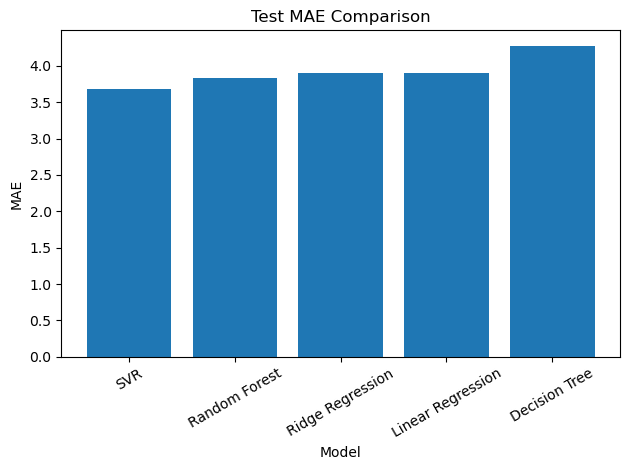

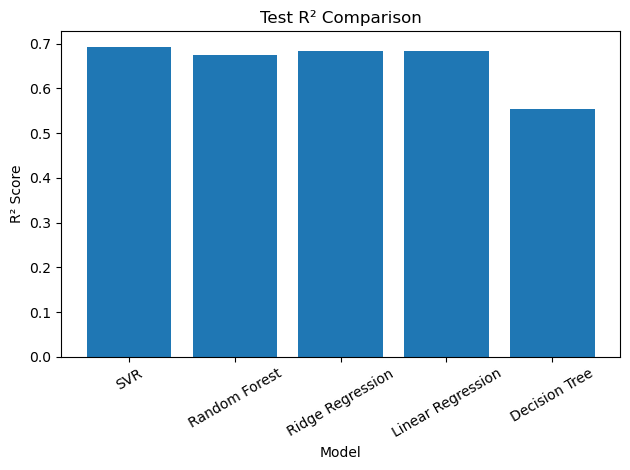

In [4]:
import matplotlib.pyplot as plt

# Ensure sorted for consistency
df = results_df.sort_values(by="Test MAE")

# --- 1. MAE comparison ---
plt.figure()
plt.bar(df["Model"], df["Test MAE"])
plt.title("Test MAE Comparison")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# --- 2. R² comparison ---
plt.figure()
plt.bar(df["Model"], df["Test R²"])
plt.title("Test R² Comparison")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

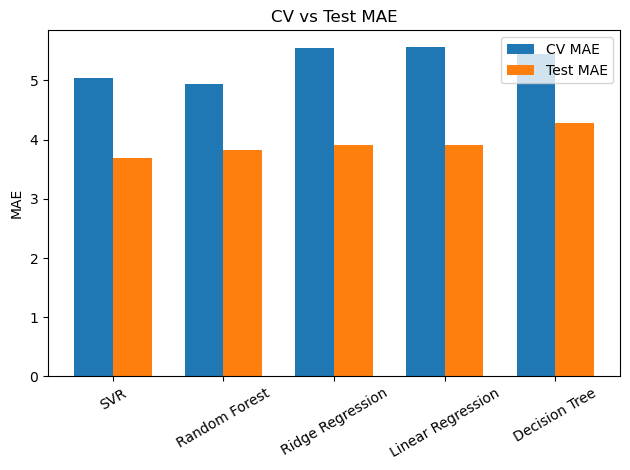

In [5]:
import numpy as np

x = np.arange(len(df))
width = 0.35

plt.figure()

plt.bar(x - width/2, df["CV MAE"], width, label="CV MAE")
plt.bar(x + width/2, df["Test MAE"], width, label="Test MAE")

plt.xticks(x, df["Model"], rotation=30)
plt.title("CV vs Test MAE")
plt.ylabel("MAE")
plt.legend()

plt.tight_layout()
plt.show()

Among the evaluated models, Support Vector Regression (SVR) achieved the best performance, with the lowest test MAE (3.68) and highest R² (0.69), indicating strong predictive accuracy. Random Forest also performed well, highlighting the importance of non-linear modelling for this dataset. Linear and Ridge regression showed similar results, suggesting limited benefit from regularisation. The Decision Tree model performed worst, likely due to overfitting and poor generalisation. Overall, models capable of capturing non-linear relationships outperformed simpler approaches.